In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)
from sklearn.preprocessing import StandardScaler


In [5]:
df = pd.read_csv('/Users/anthonyjaramillo/PycharmProjects/4900/data/processed/model_features.csv')

print(f"Shape: {df.shape}")
print(f"Seasons: {sorted(df['season'].unique())}")
print(f"Cover rate: {df['covered'].mean():.3f}")
df.head()


Shape: (2718, 24)
Seasons: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Cover rate: 0.572


,game_id,home_avg_points_scored,home_avg_points_conceded,home_avg_pass_yds_off,home_avg_pass_yds_def,home_avg_rush_yds_off,home_avg_rush_yds_def,home_avg_drives_scored_off,home_avg_drives_scored_def,away_avg_points_scored,...,away_avg_rush_yds_def,away_avg_drives_scored_off,away_avg_drives_scored_def,season,week,gameday,home_team,away_team,spread_line,covered
0,2015_02_ARI_CHI,23.0,31.0,240.0,223.0,162.0,100.0,5.0,5.0,31.0,...,54.0,5.0,5.0,2015,2,2015-09-20,CHI,ARI,-2.0,0
1,2015_02_ATL_NYG,26.0,27.0,194.0,356.0,91.0,81.0,5.0,5.0,26.0,...,63.0,6.0,4.0,2015,2,2015-09-20,NYG,ATL,2.0,0
2,2015_02_BAL_OAK,33.0,13.0,191.0,272.0,55.0,126.0,2.0,6.0,13.0,...,70.0,2.0,4.0,2015,2,2015-09-20,LV,BAL,-6.0,0
3,2015_02_DAL_PHI,24.0,26.0,336.0,300.0,63.0,98.0,4.0,6.0,27.0,...,91.0,5.0,5.0,2015,2,2015-09-20,PHI,DAL,7.0,0
4,2015_02_DEN_KC,27.0,20.0,240.0,306.0,93.0,92.0,5.0,4.0,19.0,...,73.0,4.0,2.0,2015,2,2015-09-17,KC,DEN,3.0,0


In [6]:
FEATURE_COLS = [col for col in df.columns if col.startswith(('home_avg', 'away_avg'))] + ['spread_line']

X = df[FEATURE_COLS]
y = df['covered']

# Time-based split — train on 2015-2022, test on 2023-2024
# This is more honest than random split for sports data
train_mask = df['season'] <= 2022
test_mask  = df['season'].isin([2023, 2024])

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"Training samples : {len(X_train)} ({sorted(df[train_mask]['season'].unique())})")
print(f"Testing samples  : {len(X_test)}  ({sorted(df[test_mask]['season'].unique())})")
print(f"Features         : {len(FEATURE_COLS)}")
print(f"\nFeature columns:\n{FEATURE_COLS}")


Training samples : 1950 ([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])
Testing samples  : 512  ([2023, 2024])
Features         : 17

Feature columns:
['home_avg_points_scored', 'home_avg_points_conceded', 'home_avg_pass_yds_off', 'home_avg_pass_yds_def', 'home_avg_rush_yds_off', 'home_avg_rush_yds_def', 'home_avg_drives_scored_off', 'home_avg_drives_scored_def', 'away_avg_points_scored', 'away_avg_points_conceded', 'away_avg_pass_yds_off', 'away_avg_pass_yds_def', 'away_avg_rush_yds_off', 'away_avg_rush_yds_def', 'away_avg_drives_scored_off', 'away_avg_drives_scored_def', 'spread_line']


── Logistic Regression ──────────────────────
Accuracy : 0.8125
ROC AUC  : 0.8763

              precision    recall  f1-score   support

 Not Covered       0.80      0.76      0.78       221
     Covered       0.82      0.86      0.84       291

    accuracy                           0.81       512
   macro avg       0.81      0.81      0.81       512
weighted avg       0.81      0.81      0.81       512



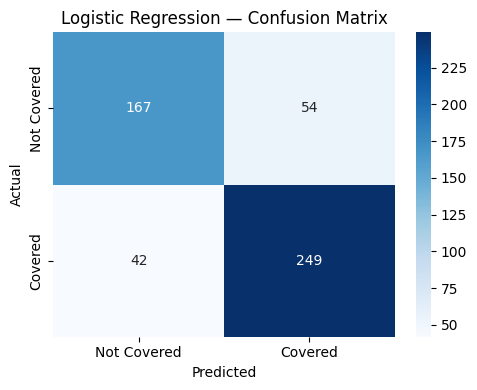

In [7]:
# Scale features — important for logistic regression
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Predict
lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("── Logistic Regression ──────────────────────")
print(f"Accuracy : {accuracy_score(y_test, lr_preds):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, lr_probs):.4f}")
print(f"\n{classification_report(y_test, lr_preds, target_names=['Not Covered', 'Covered'])}")

# Confusion matrix
cm = confusion_matrix(y_test, lr_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Covered', 'Covered'],
            yticklabels=['Not Covered', 'Covered'])
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


── Random Forest ────────────────────────────
Accuracy : 0.7812
ROC AUC  : 0.8627

              precision    recall  f1-score   support

 Not Covered       0.76      0.72      0.74       221
     Covered       0.80      0.83      0.81       291

    accuracy                           0.78       512
   macro avg       0.78      0.77      0.78       512
weighted avg       0.78      0.78      0.78       512



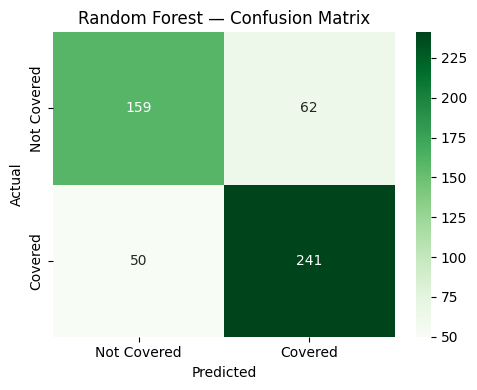

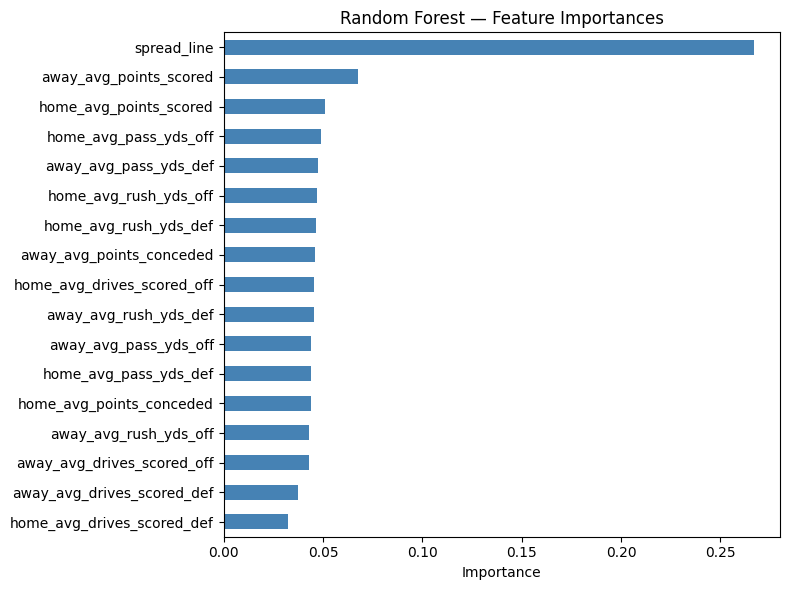

In [ ]:

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

# Evaluate
print("── Random Forest ────────────────────────────")
print(f"Accuracy : {accuracy_score(y_test, rf_preds):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, rf_probs):.4f}")
print(f"\n{classification_report(y_test, rf_preds, target_names=['Not Covered', 'Covered'])}")

# Confusion matrix
cm_rf = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Covered', 'Covered'],
            yticklabels=['Not Covered', 'Covered'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Feature importances
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Random Forest — Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


── Random Forest ────────────────────────────
Accuracy : 0.7871
ROC AUC  : 0.8627

              precision    recall  f1-score   support

 Not Covered       0.76      0.74      0.75       221
     Covered       0.81      0.82      0.81       291

    accuracy                           0.79       512
   macro avg       0.78      0.78      0.78       512
weighted avg       0.79      0.79      0.79       512



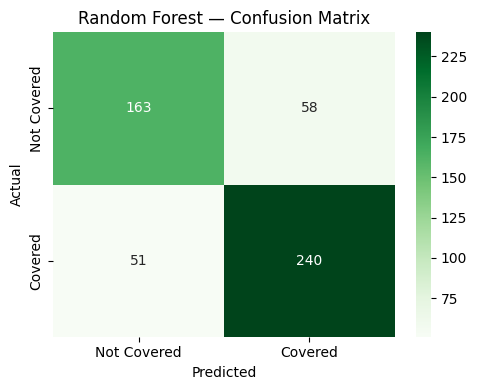

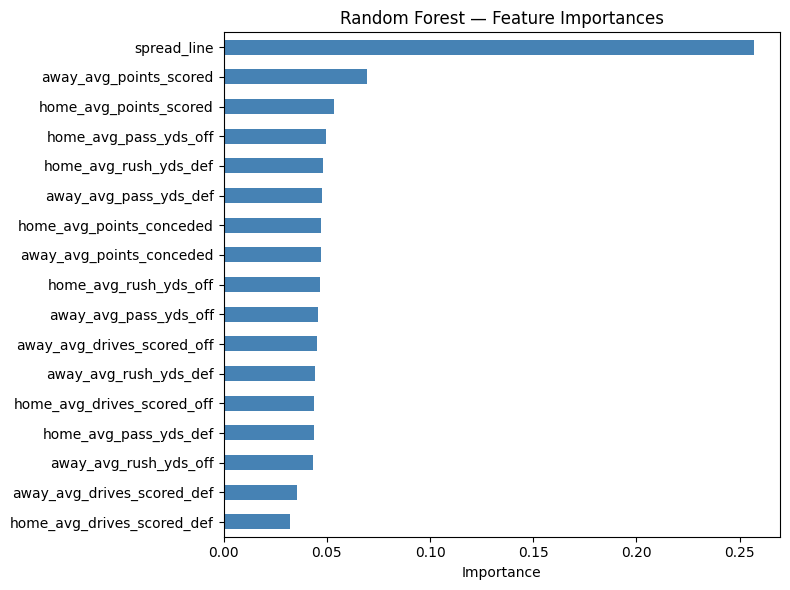

In [44]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predict
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

# Evaluate
print("── Random Forest ────────────────────────────")
print(f"Accuracy : {accuracy_score(y_test, rf_preds):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, rf_probs):.4f}")
print(f"\n{classification_report(y_test, rf_preds, target_names=['Not Covered', 'Covered'])}")

# Confusion matrix
cm_rf = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Covered', 'Covered'],
            yticklabels=['Not Covered', 'Covered'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Feature importances
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Random Forest — Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [45]:
summary = pd.DataFrame({
    'Model'   : ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, lr_preds), accuracy_score(y_test, rf_preds)],
    'ROC AUC' : [roc_auc_score(y_test, lr_probs),  roc_auc_score(y_test, rf_probs)]
}).round(4)

print(summary.to_string(index=False))
print(f"\nBaseline (always predict majority class): {max(y_test.mean(), 1-y_test.mean()):.4f}")


              Model  Accuracy  ROC AUC
Logistic Regression    0.8125   0.8763
      Random Forest    0.7871   0.8627

Baseline (always predict majority class): 0.5684


In [46]:
print(f"Overall cover rate : {y.mean():.3f}")
print(f"Train cover rate   : {y_train.mean():.3f}")
print(f"Test cover rate    : {y_test.mean():.3f}")
print(f"\nTrain seasons: {sorted(df[train_mask]['season'].unique())}")
print(f"Test seasons : {sorted(df[test_mask]['season'].unique())}")
print(f"\nTrain size: {len(y_train)}")
print(f"Test size : {len(y_test)}")


Overall cover rate : 0.572
Train cover rate   : 0.575
Test cover rate    : 0.568

Train seasons: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
Test seasons : [2023, 2024]

Train size: 1950
Test size : 512


In [47]:
lr_spread_only = LogisticRegression()
lr_spread_only.fit(X_train[['spread_line']], y_train)
preds = lr_spread_only.predict_proba(X_test[['spread_line']])[:, 1]
print(f"Spread line ONLY AUC: {roc_auc_score(y_test, preds):.4f}")


Spread line ONLY AUC: 0.8757


In [48]:
FEATURE_COLS_NO_SPREAD = [col for col in df.columns if col.startswith(('home_avg', 'away_avg'))]

X_train_ns = X_train[FEATURE_COLS_NO_SPREAD]
X_test_ns  = X_test[FEATURE_COLS_NO_SPREAD]

# Logistic Regression
scaler2 = StandardScaler()
X_train_ns_scaled = scaler2.fit_transform(X_train_ns)
X_test_ns_scaled  = scaler2.transform(X_test_ns)

lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X_train_ns_scaled, y_train)
lr2_preds = lr2.predict(X_test_ns_scaled)
lr2_probs = lr2.predict_proba(X_test_ns_scaled)[:, 1]

# Random Forest
rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2.fit(X_train_ns, y_train)
rf2_preds = rf2.predict(X_test_ns)
rf2_probs = rf2.predict_proba(X_test_ns)[:, 1]

print(f"WITH spread_line:")
print(f"  LR  AUC: {roc_auc_score(y_test, lr_probs):.4f}")
print(f"  RF  AUC: {roc_auc_score(y_test, rf_probs):.4f}")

print(f"\nWITHOUT spread_line:")
print(f"  LR  AUC: {roc_auc_score(y_test, lr2_probs):.4f}")
print(f"  RF  AUC: {roc_auc_score(y_test, rf2_probs):.4f}")

print(f"\nBaseline (majority class): {max(y_test.mean(), 1-y_test.mean()):.4f}")



WITH spread_line:
  LR  AUC: 0.8763
  RF  AUC: 0.8627

WITHOUT spread_line:
  LR  AUC: 0.7503
  RF  AUC: 0.7455

Baseline (majority class): 0.5684


In [49]:
mask_2025 = df['season'] == 2025
X_2025 = X[mask_2025]
y_2025 = y[mask_2025]

X_2025_scaled = scaler.transform(X_2025)

lr_2025_preds = lr.predict(X_2025_scaled)
rf_2025_preds = rf.predict(X_2025)
lr_2025_probs = lr.predict_proba(X_2025_scaled)[:, 1]
rf_2025_probs = rf.predict_proba(X_2025)[:, 1]

print(f"2025 LR  accuracy: {accuracy_score(y_2025, lr_2025_preds):.4f}  AUC: {roc_auc_score(y_2025, lr_2025_probs):.4f}")
print(f"2025 RF  accuracy: {accuracy_score(y_2025, rf_2025_preds):.4f}  AUC: {roc_auc_score(y_2025, rf_2025_probs):.4f}")



2025 LR  accuracy: 0.7930  AUC: 0.8657
2025 RF  accuracy: 0.7773  AUC: 0.8606


In [50]:
TOP_FEATURES = ['spread_line', 'away_avg_points_scored', 'home_avg_points_scored']

X_train_top = X_train[TOP_FEATURES]
X_test_top  = X_test[TOP_FEATURES]

# Logistic Regression
scaler_top = StandardScaler()
X_train_top_scaled = scaler_top.fit_transform(X_train_top)
X_test_top_scaled  = scaler_top.transform(X_test_top)

lr_top = LogisticRegression(max_iter=1000, random_state=42)
lr_top.fit(X_train_top_scaled, y_train)
lr_top_preds = lr_top.predict(X_test_top_scaled)
lr_top_probs = lr_top.predict_proba(X_test_top_scaled)[:, 1]

# Random Forest
rf_top = RandomForestClassifier(n_estimators=100, max_depth=5,
                                 min_samples_leaf=20, random_state=42)
rf_top.fit(X_train_top, y_train)
rf_top_preds = rf_top.predict(X_test_top)
rf_top_probs = rf_top.predict_proba(X_test_top)[:, 1]

print(f"{'Model':<25} {'Train Acc':>10} {'Test Acc':>10} {'AUC':>10}")
print("-" * 55)
print(f"{'LR (all features)':<25} {accuracy_score(y_train, lr.predict(X_train_scaled)):>10.4f} {accuracy_score(y_test, lr_preds):>10.4f} {roc_auc_score(y_test, lr_probs):>10.4f}")
print(f"{'LR (top 3)':<25} {accuracy_score(y_train, lr_top.predict(X_train_top_scaled)):>10.4f} {accuracy_score(y_test, lr_top_preds):>10.4f} {roc_auc_score(y_test, lr_top_probs):>10.4f}")
print(f"{'RF constrained (all)':<25} {accuracy_score(y_train, rf_constrained.predict(X_train)):>10.4f} {accuracy_score(y_test, rc_preds):>10.4f} {roc_auc_score(y_test, rc_probs):>10.4f}")
print(f"{'RF constrained (top 3)':<25} {accuracy_score(y_train, rf_top.predict(X_train_top)):>10.4f} {accuracy_score(y_test, rf_top_preds):>10.4f} {roc_auc_score(y_test, rf_top_probs):>10.4f}")


Model                      Train Acc   Test Acc        AUC
-------------------------------------------------------
LR (all features)             0.7615     0.8125     0.8763
LR (top 3)                    0.7569     0.8086     0.8735
RF constrained (all)          0.7826     0.7891     0.8568
RF constrained (top 3)        0.7708     0.8008     0.8654
